# Combined strain analysis : all materials, 3–8 kV

One notebook to process every material/voltage and produce the combined
**Strain vs Voltage** comparison figure (Kapton, PDMS, VHB, + bare actuator).

Run the cells top to bottom. You only edit cell 2 (`ALL_FILES`) as you add data.


**Before trusting the plot, check:** filenames point at the right material+voltage, `POUCH_LENGTH_MM` (Lp) is the same for all materials, and the diagnostic cell shows green markers sitting on the plateaus.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from google.colab import drive
drive.mount('/content/drive')

POUCH_LENGTH_MM = 29        # Lp, measured at rest. MUST be the same for every material.
DATA_FOLDER = '/content/drive/MyDrive/Thesis data'
OUT_FOLDER  = '/content/drive/MyDrive/Thesis images'

SUBTRACT_BASELINE = False    # Δl = plateau - resting level (fixes non-zero rest)
VOLT_RANGE        = range(3, 9)   # 3–8 kV

os.makedirs(OUT_FOLDER, exist_ok=True)
print('Settings loaded. Lp =', POUCH_LENGTH_MM, 'mm | baseline-subtract:', SUBTRACT_BASELINE,
      '| smooth window:', SMOOTH_WINDOW)

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif", "mathtext.fontset":"dejavusans",
    "axes.grid": False,
    "axes.edgecolor": "#666666", "axes.linewidth": 0.8,
    "xtick.color": "#444444", "ytick.color": "#444444",
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "figure.facecolor": "white", "axes.facecolor": "white", "font.size": 12,
})

COLORS  = {'Kapton': '#FBB11A', 'PDMS': '#9BC7D4', 'VHB': '#ADC179', 'Bare actuator': '#FB9990'}
MARKERS = {'Kapton': 'o', 'PDMS': 's', 'VHB': '^', 'Bare actuator': 'D'}
MAROON  = '#65091E'   # chrome only — titles, reference lines, never a data series

Mounted at /content/drive
Settings loaded. Lp = 27 mm | baseline-subtract: False | smooth window: 1


## 1. Files — edit this as you collect data

Keep the **voltage keys identical** across materials so the lines align on the x-axis.
The 5–8 kV files are filled in from your existing notebooks. Add 3 kV and 4 kV (and the
missing VHB / bare-actuator runs) by replacing the `# TODO` placeholders with real filenames.

In [2]:
ALL_FILES = {
    'Kapton': {
        # 3: '',  # TODO add 3 kV file
        4: 'K4-Tracker data processing - kapton 4kv.csv',  # TODO add 4 kV file
        5: 'K4-Tracker data processing - kapton 5kv.csv',
        6: 'K3-Tracker data processing - kapton 6kv (2).csv',
        7: 'K7-Tracker data processing - 7kv kapton.csv',
        8: 'K2-Tracker data processing - 2-8kv kapton.csv',
    },
    'PDMS': {
         #3: 'P66-Tracker data processing - pdms 6kv final .csv',  # TODO add 3 kV file
        4: 'P4-Tracker data processing - pdms 4kv.csv',  # TODO add 4 kV file
        5: '/content/drive/MyDrive/Thesis data/NP5-Tracker data processing - pdms 5kv new.csv',
        6: '/content/drive/MyDrive/Thesis data/NP6-Tracker data processing - pdms 6kv new.csv',
        7: '/content/drive/MyDrive/Thesis data/NP7-Tracker data processing - pdms 7kv new.csv',
        8: 'PT-Tracker data processing - pdms 8kv.csv',
    },
    'VHB': {
        # 3: '',  # TODO add
        4: '/content/drive/MyDrive/Thesis data/NV4-Tracker data processing - vhb 4kv new.csv',  # TODO add
        5: 'V6-Tracker data processing - vhb 5kv.csv',  # TODO add
        6: 'V55-Tracker data processing - vhb 6kv.csv',  # TODO add
        7: 'V7-Tracker data processing - vhb 7kv.csv',
        8: 'V7.5-Tracker data processing - vhb 8kv.csv',  # TODO add
    },

    #---- Bare actuator (no insulation) — uncomment and fill in as you collect them ----
     'Bare actuator': {
    #     3: '',
     4: '/content/drive/MyDrive/Thesis data/O4-Tracker data processing - original 4kv.csv',
      5: '/content/drive/MyDrive/Thesis data/O5-Tracker data processing - original 5kv.csv',
        6: '/content/drive/MyDrive/Thesis data/O6-Tracker data processing - original 6kv.csv',
         7: '/content/drive/MyDrive/Thesis data/O7-Tracker data processing - original 7kv.csv',
        8: '/content/drive/MyDrive/Thesis data/O8-Tracker data processing - original 8kv.csv',
     },
}

# Per-material held_fraction (noisier data -> lower value). Set all equal for strict consistency.
HELD = {
    'Kapton':        0.85,
    'PDMS':          0.90,
    'VHB':           0.90,
    'Bare actuator': 0.85,
}

# --Pouch length Lp (mm) per material. strain = dl / Lp
LP_MM = {
    'Kapton':        29,
    'PDMS':          29,
    'VHB':           29,
    'Bare actuator': 29,
}

#Minimum stroke (mm) for a cycle to count (min_peak_mm). Weak/low-V runs need a lower floor
DEFAULT_PEAK_FLOOR = 1.0
PEAK_FLOOR = {
    ('Kapton', 4): 0.5,
    ('PDMS',   4): 0.5,
    ('VHB',    4): 0.5,
    # add more as needed, e.g. ('VHB', 3): 0.3
}

## 2. Helper functions

`steady_state_per_cycle` detects each actuation, isolates the held-high plateau
(samples within `held_fraction` of the peak), and returns the median as the steady-state Δl —
now smoothed and baseline-subtracted.

In [3]:
def load_tracker_csv(path):
    df = pd.read_csv(path, skiprows=1)
    df = df.rename(columns={c: c.strip().lower() for c in df.columns})
    if 'y' not in df or 't' not in df:
        raise ValueError(f"Expected 't','y' columns; got {list(df.columns)}")
    return df[['t'] + [c for c in ['x', 'y'] if c in df.columns]].dropna()


def steady_state_per_cycle(df, lp_mm=None, held_fraction=0.9,
                           min_peak_mm=1, min_cycle_spacing_s=1,
                           subtract_baseline=None, smooth_window=None):
    """Per cycle: take samples >= held_fraction * peak as the held plateau, median them.
    Optionally smooth first and subtract each cycle's resting level.
    """
    if lp_mm is None:            lp_mm = POUCH_LENGTH_MM
    if subtract_baseline is None: subtract_baseline = SUBTRACT_BASELINE
    if smooth_window is None:     smooth_window = SMOOTH_WINDOW

    df = df.dropna(subset=['t', 'y']).reset_index(drop=True)
    t = df['t'].values
    y = df['y'].values.astype(float)

    # 1) smoothing: rolling median so peak / held cutoff key off the settled level, not a spike
    if smooth_window and smooth_window > 1:
        y = pd.Series(y).rolling(smooth_window, center=True, min_periods=1).median().values

    fs = 1.0 / np.median(np.diff(t))
    peaks, _ = find_peaks(y, height=min_peak_mm, distance=int(min_cycle_spacing_s * fs))
    if len(peaks) < 2:
        print(f'  warning: only {len(peaks)} peaks detected')
        return pd.DataFrame()

    mids = np.concatenate([[0], (peaks[:-1] + peaks[1:]) // 2, [len(y) - 1]])
    rows = []
    for i, p in enumerate(peaks):
        cy = y[mids[i]:mids[i + 1]]
        if len(cy) == 0:
            continue
        peak_val = y[p]
        held = cy[cy >= held_fraction * peak_val]
        if len(held) < 3:
            continue
        dl_high = float(np.median(held))

        # 2) per-cycle baseline = median of this cycle's low (resting) samples
        baseline = 0.0
        if subtract_baseline:
            cmin = cy.min()
            low = cy[cy <= cmin + 0.20 * (peak_val - cmin)]
            if len(low):
                baseline = float(np.median(low))

        dl_steady = dl_high - baseline
        rows.append({
            't_peak':         float(t[p]),
            'dl_peak':        float(peak_val),
            'dl_baseline':    baseline,
            'dl_steady':      dl_steady,
            'n_held_samples': int(len(held)),
            'strain':         dl_steady / lp_mm * 100,
        })
    return pd.DataFrame(rows)

## 3. Process everything → summary table

Computes mean ± std strain at each voltage for every material and saves a combined CSV.

In [4]:
combined = {}
summary_all = []
for material, files in ALL_FILES.items():
    rows = []
    for v in VOLT_RANGE:
        fname = files.get(v)
        if not fname:
            continue
        path = os.path.join(DATA_FOLDER, fname)
        if not os.path.exists(path):
            print(f'{material} {v} kV: file not found ({fname})')
            continue
        lp    = LP_MM.get(material, POUCH_LENGTH_MM)
        floor = PEAK_FLOOR.get((material, v), DEFAULT_PEAK_FLOOR)
        cycles = steady_state_per_cycle(load_tracker_csv(path),
                                        lp_mm=lp,
                                        held_fraction=HELD.get(material, 0.9),
                                        min_peak_mm=floor)
        if len(cycles) == 0:
            print(f'{material} {v} kV: no cycles detected')
            continue
        row = {'voltage_kV': v,
               'mean_strain_%': cycles['strain'].mean(),
               'std_strain_%':  cycles['strain'].std(),
               'n_cycles':      len(cycles)}
        rows.append(row)
        summary_all.append({'material': material, **row})
    combined[material] = pd.DataFrame(rows)

summary_df = pd.DataFrame(summary_all)
print(summary_df.round(2).to_string(index=False))
summary_df.to_csv(os.path.join(OUT_FOLDER, 'strain_vs_voltage_ALL.csv'), index=False)
print('\nSaved: strain_vs_voltage_ALL.csv')

     material  voltage_kV  mean_strain_%  std_strain_%  n_cycles
       Kapton           4           1.89          0.19         2
       Kapton           5           5.62          0.30         8
       Kapton           6           6.87          0.43        10
       Kapton           7           7.83          0.30         9
       Kapton           8           8.40          0.41        11
         PDMS           4           4.04          0.65         9
         PDMS           5           6.45          0.35         9
         PDMS           6           7.97          0.41         8
         PDMS           7           8.17          0.26         9
         PDMS           8          10.10          0.45         9
          VHB           4           4.41          0.28         8
          VHB           5           5.31          0.55         9
          VHB           6           5.76          0.71         8
          VHB           7           6.77          0.41         8
          VHB           8

## 4. Combined plot — the thesis comparison figure

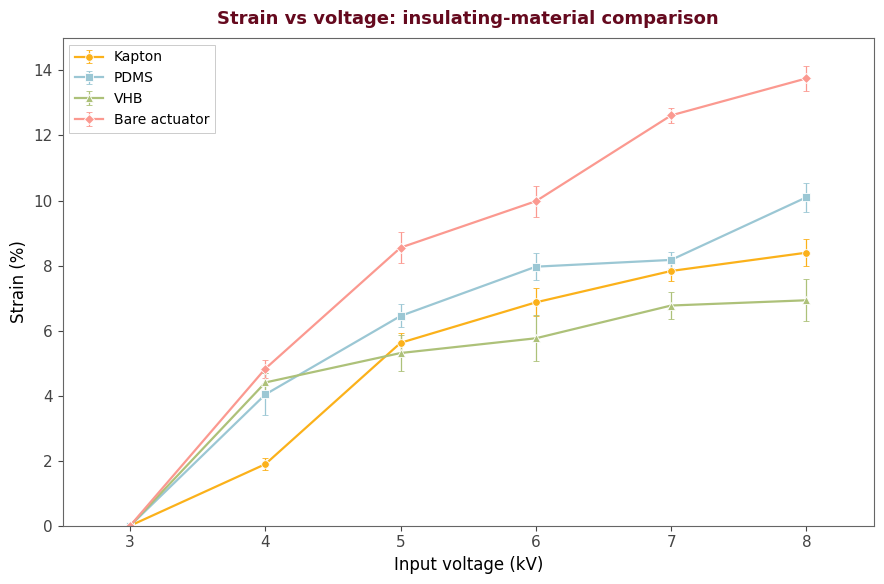

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
for material, s in combined.items():
    if len(s) == 0:
        continue
    s = s.sort_values('voltage_kV')
    if not (s['voltage_kV'].round(1) == 3.0).any():
        anchor = pd.DataFrame({'voltage_kV': [3.0], 'mean_strain_%': [0.0], 'std_strain_%': [0.0]})
        s = pd.concat([anchor, s], ignore_index=True).sort_values('voltage_kV')
    c = COLORS.get(material, '#888888')
    ax.errorbar(s['voltage_kV'], s['mean_strain_%'], yerr=s['std_strain_%'],
                fmt=MARKERS.get(material, 'o') + '-', color=c, ecolor=c,
                markersize=5.5, markerfacecolor=c, markeredgecolor='white', markeredgewidth=0.6,
                capsize=2.5, elinewidth=0.9, linewidth=1.6, label=material)

ax.set_xlabel('Input voltage (kV)')
ax.set_ylabel('Strain (%)')
ax.set_title('Strain vs voltage: insulating-material comparison',
             color=MAROON, fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(2.5, 8.5)
ax.set_ylim(0, 15)

# optional cohesion accent — operating voltage (delete these 2 lines if you don't want it)
#ax.axvline(8.0, color=MAROON, lw=1.3, ls='--')
#ax.text(7.9, 14.3, 'operating  8 kV', color=MAROON, fontsize=9, ha='right', style='normal')

ax.legend(frameon=True, fontsize=10, edgecolor='#cccccc',
          framealpha=1, fancybox=False).get_frame().set_linewidth(0.7)

plt.tight_layout()
base = os.path.join(OUT_FOLDER, 'strain_vs_voltage_ALL')
plt.savefig(base + '.pdf', bbox_inches='tight', facecolor='white')   # LaTeX thesis
plt.savefig(base + '.svg', bbox_inches='tight', facecolor='white')   # PowerPoint (sharp, editable)
#plt.savefig(base + '.png', dpi=300, bbox_inches='tight', facecolor='white')  # quick preview
#plt.savefig(os.path.join(OUT_FOLDER, 'strain_vs_voltage_ALL.png'), dpi=800, facecolor='white')
#plt.savefig(base + '.pdf', bbox_inches='tight', facecolor='white')
plt.show()

## 5. Single-file diagnostic (tuning)

Use this to eyeball one trace and tune `held_fraction` for that material: the green
markers should sit in the middle of each plateau. If they ride near the red peaks, lower
the value in `HELD`; if they drop onto the rising/falling edges, raise it.

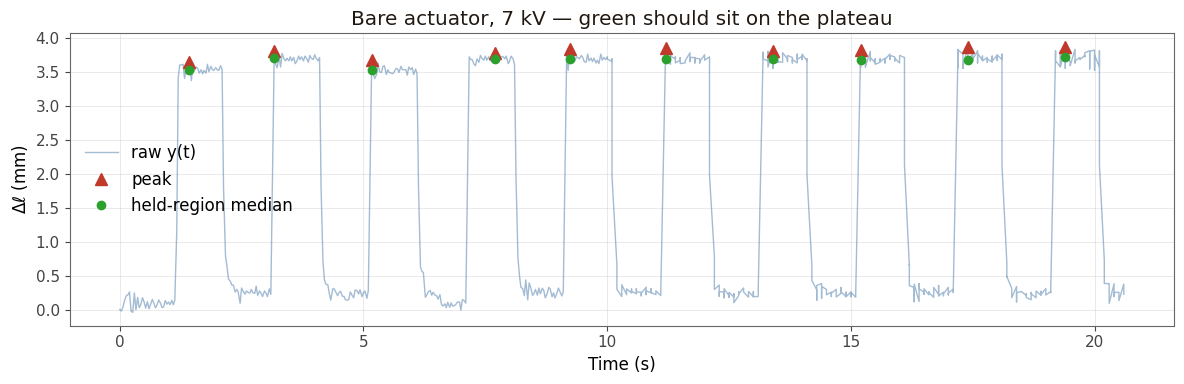

 t_peak  dl_peak  dl_baseline  dl_steady  strain
   1.43     3.65          0.0       3.53  12.172
   3.17     3.80          0.0       3.70  12.759
   5.17     3.67          0.0       3.53  12.172
   7.70     3.77          0.0       3.69  12.724
   9.23     3.84          0.0       3.69  12.724
  11.20     3.85          0.0       3.69  12.724
  13.40     3.81          0.0       3.69  12.724
  15.20     3.82          0.0       3.68  12.690
  17.40     3.86          0.0       3.68  12.690
  19.40     3.87          0.0       3.71  12.793


In [6]:
CHECK_MATERIAL = 'Bare actuator'
CHECK_VOLTAGE  = 7

fname = ALL_FILES.get(CHECK_MATERIAL, {}).get(CHECK_VOLTAGE)
path = os.path.join(DATA_FOLDER, fname) if fname else None
if path and os.path.exists(path):
    df  = load_tracker_csv(path)
    lp    = LP_MM.get(CHECK_MATERIAL, POUCH_LENGTH_MM)
    floor = PEAK_FLOOR.get((CHECK_MATERIAL, CHECK_VOLTAGE), DEFAULT_PEAK_FLOOR)
    cyc = steady_state_per_cycle(df, lp_mm=lp,
                                 held_fraction=HELD.get(CHECK_MATERIAL, 0.9),
                                 min_peak_mm=floor)
    plt.figure(figsize=(12, 4))
    plt.plot(df['t'], df['y'], color='#4878a8', alpha=0.5, lw=1.0, label='raw y(t)')
    plt.plot(cyc['t_peak'], cyc['dl_peak'], '^', color='#c0392b', ms=8, label='peak')
    plt.plot(cyc['t_peak'], cyc['dl_steady'] + cyc['dl_baseline'], 'o', color='#2ca02c', ms=6,
             label='held-region median')
    plt.xlabel('Time (s)'); plt.ylabel(r'$\Delta\ell$ (mm)')
    plt.title(f'{CHECK_MATERIAL}, {CHECK_VOLTAGE} kV — green should sit on the plateau', color='#211811')
    plt.grid(True, alpha=0.3, linewidth=0.6)   # explicitly on: useful for a QC plot
    plt.legend(frameon=False); plt.tight_layout(); plt.show()
    print(cyc[['t_peak', 'dl_peak', 'dl_baseline', 'dl_steady', 'strain']].round(3).to_string(index=False))
else:
    print('Set CHECK_MATERIAL / CHECK_VOLTAGE to a file that exists in ALL_FILES.')

In [7]:
# ============ FREQUENCY SWEEP SETTINGS ============
FREQ_VOLTAGE_KV = 6       # the fixed voltage all frequency tests were run at (for titles)
TRANSIENT_S     = 0.3      # seconds to drop at the start (settling)

FREQ_FILES = {
    'PDMS': {
        # 1:  '',
        # 2:  '',
        # 5:  '',
        10: 'P10hz-Tracker data processing - pdms 10hz.csv',
    },
    'Kapton':        {},
    'VHB': {
    1:  'V1hz-Tracker data processing - vhb 1hz.csv',
    2:  'V2hz-Tracker data processing - vhb 2hz.csv',
    5:  'V5hz-Tracker data processing - vhb 5hz.csv',
    10: 'V10hz-Tracker data processing - vhb 10hz.csv',
},
    'Bare actuator': {},
}
# reuses LP_MM, POUCH_LENGTH_MM, DATA_FOLDER, OUT_FOLDER from the voltage notebook

In [8]:
def freq_amplitude(df, f_drive, lp_mm=None, transient_s=None,
                   min_spc=4, hold_frac=0.6, min_cycles=4):
    """Square-wave drive: per-cycle peak-to-peak stroke (high plateau - low plateau).
    Tightened: drops partial first/last cycles, trims the single most extreme cycle
    before computing spread, and requires a minimum number of clean cycles.
    """
    if lp_mm is None:       lp_mm = POUCH_LENGTH_MM
    if transient_s is None: transient_s = TRANSIENT_S

    df = df.dropna(subset=['t', 'y']).reset_index(drop=True)
    t = df['t'].values.astype(float)
    y = df['y'].values.astype(float)
    dt = np.median(np.diff(t)); fs = 1 / dt
    spc = fs / f_drive

    m = t >= transient_s
    t2, y2 = t[m], y[m]
    if len(y2) < 8:
        return None

    # per-cycle amplitude = (high plateau - low plateau) / 2, median-based
    T = max(2, int(round(fs / f_drive)))
    amps = []
    for s in range(0, len(y2) - T + 1, T):
        seg = np.sort(y2[s:s + T])
        k = max(1, int(len(seg) * (1 - hold_frac) / 2))
        low  = np.median(seg[:k])
        high = np.median(seg[-k:])
        amps.append((high - low) / 2)
    amps = np.array(amps)

    # tightening step 1: drop first & last cycle (usually partial/clipped)
    if len(amps) >= min_cycles + 2:
        amps = amps[1:-1]

    if len(amps) < min_cycles:
        print(f'  warning: only {len(amps)} clean cycles at {f_drive} Hz')
        return None

    amp = float(np.median(amps))            # robust central amplitude

    # tightening step 2: trim the single most extreme cycle for the spread
    if len(amps) >= 5:
        med = np.median(amps)
        trimmed = np.delete(amps, np.argmax(np.abs(amps - med)))
    else:
        trimmed = amps
    std = float(trimmed.std())

    # measured frequency (FFT) as a frame-rate sanity check
    yd = (y2 - y2.mean()) * np.hanning(len(y2))
    freqs = np.fft.rfftfreq(len(yd), dt)
    f_meas = freqs[np.argmax(np.abs(np.fft.rfft(yd)))]

    return {
        'freq_set_Hz':       f_drive,
        'freq_meas_Hz':      f_meas,
        'amp_mm':            amp,
        'strain_amp_%':      amp / lp_mm * 100,
        'strain_amp_std_%':  std / lp_mm * 100,
        'xcheck_pp_%':       amp * 2 / lp_mm * 100,
        'samples_per_cycle': spc,
        'undersampled':      spc < min_spc,
        'n_cycles':          len(amps),
    }

In [9]:
freq_combined, freq_rows = {}, []
for material, files in FREQ_FILES.items():
    rows = []
    for f, fname in sorted(files.items()):
        if not fname:
            continue
        path = os.path.join(DATA_FOLDER, fname)
        if not os.path.exists(path):
            print(f'{material} {f} Hz: file not found ({fname})')
            continue
        r = freq_amplitude(load_tracker_csv(path), f,
                           lp_mm=LP_MM.get(material, POUCH_LENGTH_MM))
        if r is None:
            print(f'{material} {f} Hz: too few samples')
            continue
        flag = '   <-- UNDERSAMPLED' if r['undersampled'] else ''
        print(f"{material:14s} {f:5.1f} Hz: strain amp {r['strain_amp_%']:.2f}%  "
              f"(meas {r['freq_meas_Hz']:.1f} Hz, {r['samples_per_cycle']:.1f} spc, "
              f"{r['n_cycles']} cyc){flag}")
        rows.append(r); freq_rows.append({'material': material, **r})
        freq_combined[material] = pd.DataFrame(rows)

freq_df = pd.DataFrame(freq_rows)
if len(freq_df):
    print('\n', freq_df.round(2).to_string(index=False))
    freq_df.to_csv(os.path.join(OUT_FOLDER, 'strain_vs_frequency_ALL.csv'), index=False)
    print('\nSaved: strain_vs_frequency_ALL.csv')

PDMS 10 Hz: file not found (P10hz-Tracker data processing - pdms 10hz.csv)
VHB              1.0 Hz: strain amp 1.91%  (meas 1.0 Hz, 58.8 spc, 12 cyc)
VHB              2.0 Hz: strain amp 2.07%  (meas 1.7 Hz, 25.0 spc, 19 cyc)
VHB              5.0 Hz: strain amp 1.43%  (meas 4.2 Hz, 10.0 spc, 25 cyc)
VHB             10.0 Hz: strain amp 1.53%  (meas 0.4 Hz, 5.9 spc, 19 cyc)

 material  freq_set_Hz  freq_meas_Hz  amp_mm  strain_amp_%  strain_amp_std_%  xcheck_pp_%  samples_per_cycle  undersampled  n_cycles
     VHB            1          0.98    0.52          1.91              0.16         3.81              58.82         False        12
     VHB            2          1.65    0.56          2.07              0.12         4.14              25.00         False        19
     VHB            5          4.17    0.39          1.43              0.43         2.86              10.00         False        25
     VHB           10          0.45    0.41          1.53              0.48         3.06        

In [10]:
CHECK_MATERIAL = 'PDMS'
CHECK_FREQ     = 10

fname = FREQ_FILES.get(CHECK_MATERIAL, {}).get(CHECK_FREQ)
path = os.path.join(DATA_FOLDER, fname) if fname else None
if path and os.path.exists(path):
    df = load_tracker_csv(path)
    t = df['t'].values; y = df['y'].values
    dt = np.median(np.diff(t))
    yd = (y - y.mean()) * np.hanning(len(y))
    freqs = np.fft.rfftfreq(len(yd), dt)
    amp = np.abs(np.fft.rfft(yd)) * 2 / np.sum(np.hanning(len(y)))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(t, y, color='steelblue'); ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Δl (mm)')
    ax1.set_title(f'{CHECK_MATERIAL}, {CHECK_FREQ} Hz — raw trace'); ax1.grid(alpha=0.3)
    ax2.plot(freqs, amp, color='darkorange'); ax2.axvline(CHECK_FREQ, ls='--', color='gray')
    ax2.set_xlim(0, 5 * CHECK_FREQ); ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Amplitude (mm)'); ax2.set_title('Spectrum — peak should sit at the drive freq')
    ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('Set CHECK_MATERIAL / CHECK_FREQ to a file that exists.')

Set CHECK_MATERIAL / CHECK_FREQ to a file that exists.


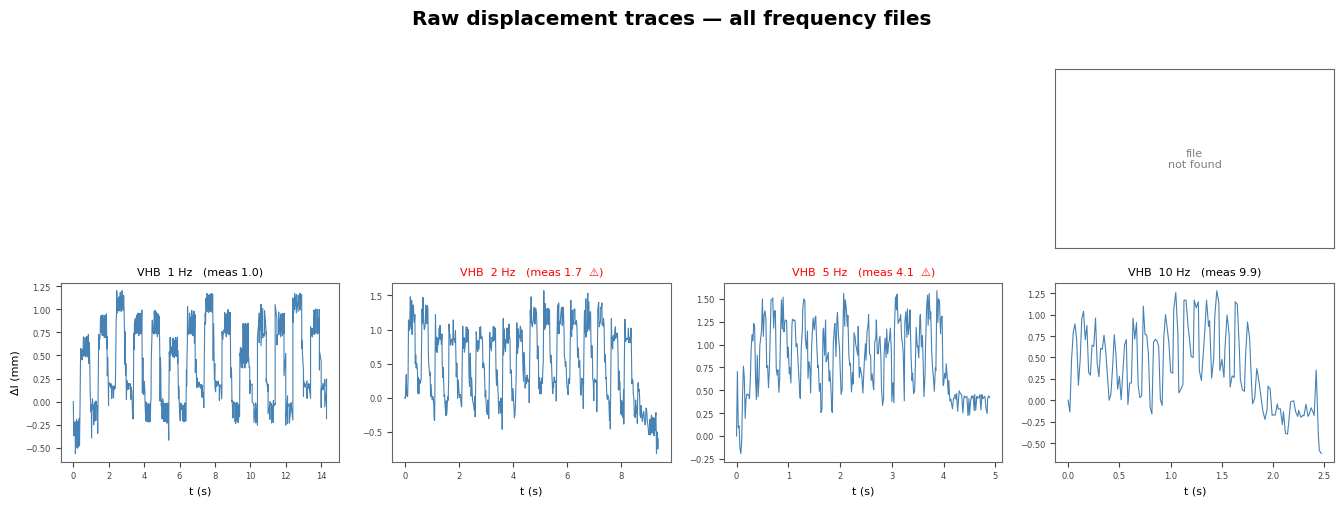

In [11]:
# Raw displacement traces for every frequency file — visual QC gallery
all_freqs = sorted({f for files in FREQ_FILES.values() for f in files if files.get(f)})
mats = [m for m, files in FREQ_FILES.items() if any(files.values())]

if not all_freqs or not mats:
    print('No frequency files filled in yet.')
else:
    nrows, ncols = len(mats), len(all_freqs)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 2.5 * nrows),
                             squeeze=False)
    for i, mat in enumerate(mats):
        for j, f in enumerate(all_freqs):
            ax = axes[i][j]
            fname = FREQ_FILES[mat].get(f)
            if not fname:
                ax.axis('off'); continue
            path = os.path.join(DATA_FOLDER, fname)
            if not os.path.exists(path):
                ax.text(0.5, 0.5, 'file\nnot found', ha='center', va='center',
                        fontsize=8, color='gray')
                ax.set_xticks([]); ax.set_yticks([])
            else:
                df = load_tracker_csv(path)
                t, y = df['t'].values, df['y'].values
                ax.plot(t, y, color='steelblue', lw=0.8)
                # measured frequency (FFT) — flags the frame-rate bug at a glance
                dt = np.median(np.diff(t))
                yd = (y - y.mean()) * np.hanning(len(y))
                fm = np.fft.rfftfreq(len(yd), dt)[np.argmax(np.abs(np.fft.rfft(yd)))]
                bad = abs(fm - f) / f > 0.1          # >10% off = suspicious
                ax.set_title(f'{mat}  {f} Hz)',
                             fontsize=8, color=('red' if bad else 'black'))
                ax.tick_params(labelsize=6)
            if i == nrows - 1: ax.set_xlabel('t (s)', fontsize=8)
            if j == 0:         ax.set_ylabel('Δl (mm)', fontsize=8)
    fig.suptitle('Raw displacement traces — all frequency files',
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FOLDER, 'freq_raw_traces_ALL.png'), dpi=150,
                bbox_inches='tight')
    plt.show()

NameError: name 'line' is not defined

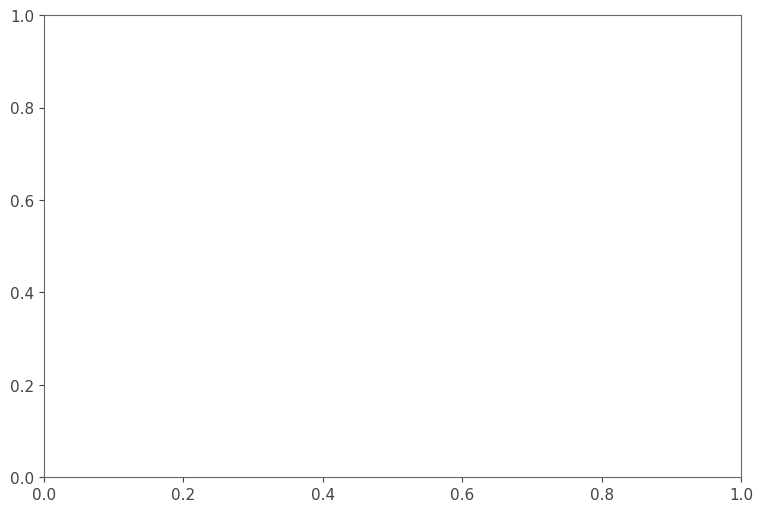

In [12]:
# Normalized strain vs frequency — each material ÷ its own lowest-freq value =====
fig, ax = plt.subplots(figsize=(9, 6))
markers = ['o', 's', '^', 'D', 'v']

for (mat, s), mk in zip(freq_combined.items(), markers):
    if len(s) < 2:          # need at least 2 points to show a roll-off
        continue
    s = s.sort_values('freq_set_Hz')
    f   = s['freq_set_Hz'].values
    amp = s['strain_amp_%'].values
    err = s['strain_amp_std_%'].values

    ref = amp[0]                         # lowest-frequency amplitude = the denominator
    if ref == 0:
        continue
    norm     = amp / ref * 100           # 100% at the lowest frequency
    norm_err = err / ref * 100           # error bars scaled by the same factor

    #line = ax.errorbar(f, norm, yerr=norm_err, fmt=mk, ms=7, capsize=4,
                       #ls='none', label=mat)

    npts = len(f)
    if npts >= 3:
        deg = 3 if npts >= 6 else (2 if npts >= 4 else 1)
        xf = np.linspace(f.min(), f.max(), 200)
        ax.plot(xf, np.polyval(np.polyfit(f, norm, deg), xf), '-', lw=1.5,
                color=line[0].get_color())

# -3 dB reference line = bandwidth marker
ax.axhline(70.7, ls=':', color='gray', lw=1)
ax.text(ax.get_xlim()[1], 71.5, '-3 dB (bandwidth)', color='gray',
        fontsize=9, ha='right')

ax.set_xlabel('Frequency (Hz)', fontweight='bold')
ax.set_ylabel('Normalized Strain (%)', fontweight='bold')
ax.set_title(f'Normalized Strain % vs Frequency at {FREQ_VOLTAGE_KV} kV', fontweight='bold')
ax.set_ylim(40, 105)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_FOLDER, 'normalized_strain_vs_frequency_ALL.png'),
            dpi=200, bbox_inches='tight')
plt.show()